# COMP8038 - Computational Intelligence I Exam<br><small>Appendix: Case 02. Artificial Bee Colony Algorithm<br>2340081121 / Nicholas Dominic<br>BINUS University Graduate Program</small>

In [1]:
from beecolpy import abc
from numpy import array
from matplotlib.pyplot import scatter, legend, figure, title, tight_layout as tl

In [2]:
help(abc)

Help on class abc in module beecolpy.beecolpy:

class abc(builtins.object)
 |  abc(function, boundaries, colony_size: int = 40, scouts: float = 0.5, iterations: int = 50, min_max: str = 'min', nan_protection: bool = True, log_agents: bool = True)
 |  
 |  Class that applies Artificial Bee Colony (ABC) algorithm to find 
 |  minimum or maximum of a function that's receive a vector of floats 
 |  as input and returns a float as output.
 |  
 |  https://en.wikipedia.org/wiki/Artificial_bee_colony_algorithm
 |  
 |  Parameters
 |  ----------
 |  function : Name
 |      A name of a function to minimize/maximize.
 |      Example: if the function is:
 |          def my_func(x): return x[0]**2 + x[1]**2 + 5*x[1]
 |          
 |          Use "my_func" as parameter.
 |  
 |  
 |  boundaries : List of Tuples
 |      A list of tuples containing the lower and upper boundaries of 
 |      each dimension of function domain.
 |      
 |      Obs.: The number of boundaries determines the dimension of 


In [3]:
def rosenbrock_function(data):
    # data is in form of [x, y]
    return (100 * (data[1]-(data[0]**2))**2) + (1-data[0])**2

In [4]:
def fit(colony_size=100, sct=.5, it=50):
    # register the function and set the function boundaries to (-10 <= x <= 10 and -10 <= y <= 10)
    abc_obj = abc(rosenbrock_function, [(-10, 10), (-10, 10)], colony_size=colony_size, scouts=sct, iterations=it)
    return colony_size, it, abc_obj.fit() # execute the algorithm

In [5]:
glob_minimum = []
for i in range(50, 500+1, 50):
    glob_minimum.append(fit(colony_size=i))

In [6]:
glob_minimum

[(50, 50, [1.0614937015831283, 1.1231082648792756]),
 (100, 50, [1.0002679352244497, 1.0035552904125844]),
 (150, 50, [1.0027111171615593, 1.002676580163669]),
 (200, 50, [1.0318801371972472, 1.0632023972382287]),
 (250, 50, [1.0187342310600407, 1.0408214032228578]),
 (300, 50, [0.9244910216023513, 0.8500673544444339]),
 (350, 50, [1.0668880465233845, 1.1368746189324854]),
 (400, 50, [0.9996355936318587, 1.0007945345069826]),
 (450, 50, [1.0055994352307687, 1.0115850812962093]),
 (500, 50, [0.9612167541726868, 0.9239736681647477])]

In [7]:
best_colony = 0
total_solution_colony = float('inf')

for i in glob_minimum:
    if i[2][0]+i[2][1] < total_solution_colony:
        total_solution_colony = i[2][0]+i[2][1]
        best_colony = i[0]

In [8]:
best_colony

300

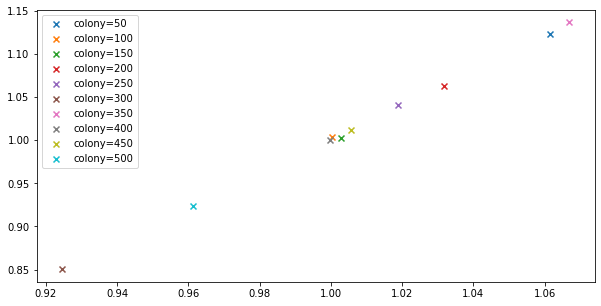

In [9]:
fig = figure(figsize=(10, 5))
for i, j, k in glob_minimum:
    scatter(k[0], k[1], marker="x", label="colony={}".format(i))
    legend(loc='best')

In [10]:
glob_minimum_it = []
for i in range(100, 550, 50):
    glob_minimum_it.append(fit(it=i))

In [11]:
glob_minimum_it

[(100, 100, [1.0884544122479265, 1.1782312559771204]),
 (100, 150, [0.9642230186981521, 0.9289877827578662]),
 (100, 200, [0.9884399882891134, 0.9764325387504788]),
 (100, 250, [0.9720813811174448, 0.9451575917648795]),
 (100, 300, [1.0302450190786185, 1.0686109351671176]),
 (100, 350, [1.0003063053102126, 0.9989429211734444]),
 (100, 400, [0.9766788317308032, 0.95270277678942]),
 (100, 450, [0.9553006951422742, 0.9150788959121476]),
 (100, 500, [0.9689321781102472, 0.9380894650191591])]

In [12]:
best_iter = 0
total_solution_iter = float('inf')

for i in glob_minimum_it:
    if i[2][0]+i[2][1] < total_solution_iter:
        total_solution_iter = i[2][0]+i[2][1]
        best_iter = i[1]

In [13]:
best_iter

450

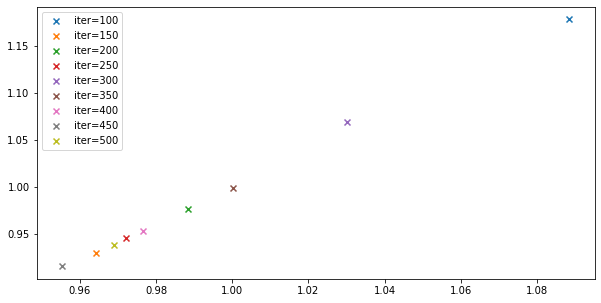

In [14]:
fig2 = figure(figsize=(10, 5))
for i, j, k in glob_minimum_it:
    scatter(k[0], k[1], marker="x", label="iter={}".format(j))
    legend(loc='best')

In [15]:
abc_obj = abc(rosenbrock_function, [(-10, 10), (-10, 10)], colony_size=best_colony, scouts=.5, iterations=best_iter)
abc_obj.fit() #Execute the algorithm

[1.0033940913810635, 1.0071636321643933]

In [16]:
# get the obtained solution after execute the fit() method
abc_obj.get_solution()

[1.0033940913810635, 1.0071636321643933]

In [17]:
# get number of times that scout event occur
abc_obj.get_status()[1]

250

In [18]:
# get a list with position of all points (food sources) used in each iteration
abc_obj.get_agents()

[[[1.1118790649512746, -0.9447163337475466],
  [2.0297413562586186, 8.726003917987732],
  [7.940957500738325, -1.713074961224736],
  [1.4632370812420668, 3.067604098660796],
  [9.425058622738, 1.274633274634489],
  [-3.949909649013903, -8.42158988540052],
  [0.7495852494689501, -4.65569907200557],
  [-6.182141056202182, -2.3986019975033095],
  [-9.516599112259323, 9.906570252139474],
  [-0.02976789378371869, 6.16241927715819],
  [-8.11272683399629, -9.768533902768029],
  [2.012245477261242, -9.511751911355839],
  [-2.6425446826383014, -8.199241095422352],
  [1.87842201828823, 7.5967814607659],
  [6.486699214383851, 9.516613105103193],
  [4.856773931767414, -6.32930275489195],
  [0.8726852130231872, 9.03472403908195],
  [-5.787560297041933, -3.0816627365070426],
  [-0.3219456749803218, -6.718441918731395],
  [2.2983547454930164, -3.7208506758149724],
  [3.939737354535083, 6.820060195424983],
  [1.7359783665474442, 4.9681231970921065],
  [-0.825481181875622, -0.21400877756301284],
  [4.7

In [19]:
selected_num_of_iter = list(range(0, len(abc_obj.get_agents()), int((len(abc_obj.get_agents()))/14)))

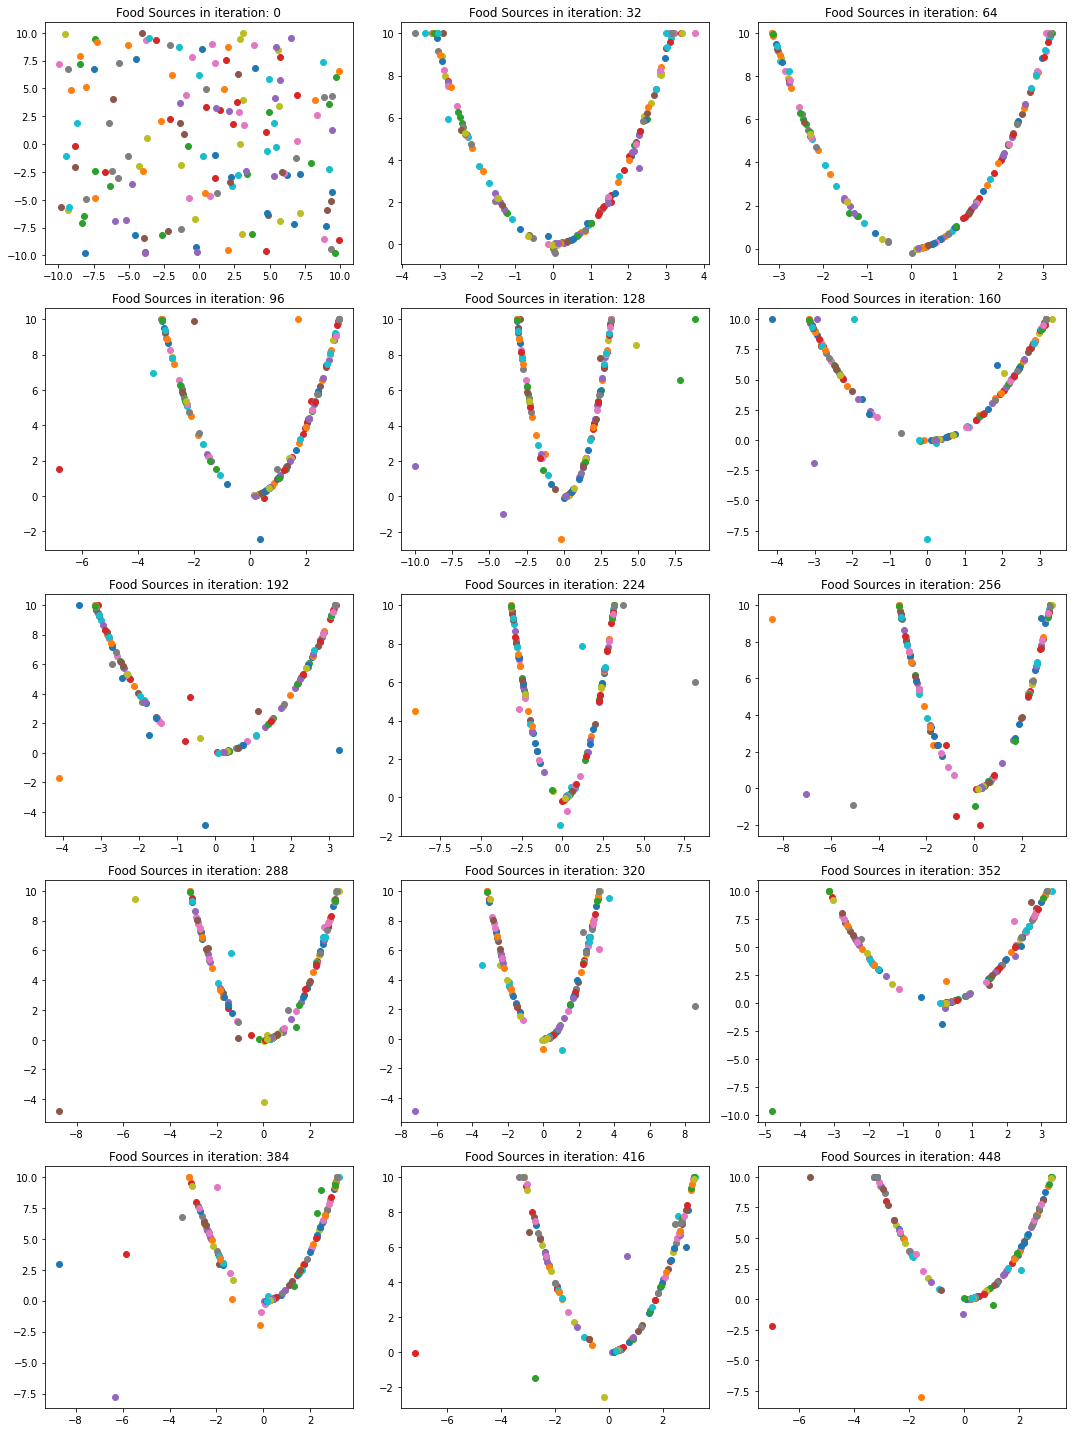

In [20]:
fig3 = figure(figsize=(15, 20))
for a, b in enumerate(selected_num_of_iter):
    x = fig3.add_subplot(5, 3, a+1) # position index always starts from 1, thus i+1
    for i in abc_obj.get_agents()[b]:
        scatter(i[0], i[1])
        title("Food Sources in iteration: {}".format(b))
tl() # margin is adjusted